# 14 - Marker probe for InvA ghost shifts

This tests the simple idea: add a tiny unnatural marker, run the same gain-matched `InvA` initialization, subtract the no-marker reconstruction, and read where the marker ghosts moved.

Because the forward/recon path is linear, this can also be used on corrected scanner data by injecting `AFinal @ marker` into the data before `InvA`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from PIL import Image
import scipy.io
import torch
import torch.nn.functional as F

torch.set_grad_enabled(False)
plt.rcParams["figure.dpi"] = 120

ROOT = Path("/home/data1/musong/workspace/python/spen_recons")
SPENPY_ROOT = ROOT / "spenpy"
if str(SPENPY_ROOT) not in sys.path:
    sys.path.insert(0, str(SPENPY_ROOT))

from spenpy.core import calcInvA

MAT_PATH = ROOT / "data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat"
IMG_PATH = SPENPY_ROOT / "spenpy/data/brain.png"


def pil_to_float_tensor(path: Path) -> torch.Tensor:
    image = Image.open(path).convert("L")
    data = torch.frombuffer(bytearray(image.tobytes()), dtype=torch.uint8).float()
    return data.reshape(image.height, image.width) / 255.0


def build_scanner_matrices(mat_path: Path):
    mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    args = torch.as_tensor(mat["calc_inva_params"].full_args, dtype=torch.float64).flatten()
    inv_a, a_final = calcInvA(
        args[0], args[1], int(args[2].item()), args[3], int(args[4].item()), args[5], args[6]
    )
    return inv_a.to(torch.complex64), a_final.to(torch.complex64), args


def fit_complex_gain(source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    denom = source.abs().square().sum().real.clamp_min(1e-12)
    return (source.conj() * target).sum() / denom


def nrmse(value: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
    return torch.linalg.vector_norm(value - reference) / torch.linalg.vector_norm(reference).clamp_min(1e-12)


def robust_abs01(value: torch.Tensor, percentile: float = 99.5) -> torch.Tensor:
    value = value.abs() if torch.is_complex(value) else value.float().abs()
    positive = value[value > 0]
    scale = torch.quantile(positive, percentile / 100.0).clamp_min(1e-8) if positive.numel() else value.new_tensor(1.0)
    return torch.clamp(value / scale, 0.0, 1.0)


def show(ax, value, title, cmap="gray", vmin=None, vmax=None, colorbar=False):
    image = value.detach().cpu() if isinstance(value, torch.Tensor) else value
    im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

## 1. Gain-matched InvA baseline

This is the same clean synthetic path as notebook 12: `y = AFinal @ image`, then `gain * InvA @ y`.

In [2]:
InvA, AFinal, scanner_args = build_scanner_matrices(MAT_PATH)
pe = AFinal.shape[0]

img = pil_to_float_tensor(IMG_PATH)
x_true = F.interpolate(img[None, None], size=(pe, pe), mode="bilinear", align_corners=False)[0, 0]
x_true = x_true.to(torch.complex64).unsqueeze(0)

y = AFinal @ x_true
x0_raw = InvA @ y
data_gain = fit_complex_gain(AFinal @ x0_raw, y)
x0 = data_gain * x0_raw
M_gain = data_gain * (InvA @ AFinal)

print("matrix size:", pe)
print(f"data-derived gain: {data_gain.item():.4g}")
print(f"gain-matched InvA image NRMSE: {nrmse(x0.abs(), x_true.abs()).item():.5f}")
print(f"||gain * InvA @ AFinal - I|| / ||I||: {nrmse(M_gain, torch.eye(pe, dtype=M_gain.dtype)):.5f}")

matrix size: 96
data-derived gain: 19.57+0.0776j
gain-matched InvA image NRMSE: 0.10718
||gain * InvA @ AFinal - I|| / ||I||: 0.47725


## 2. Add impossible pixels

The marker is sparse and complex-valued, so it is easy to separate from normal magnitude anatomy. The subtraction below isolates only the marker response.

In [3]:
def make_sparse_marker(shape, base_image, strength=0.35):
    _, height, width = shape
    marker = torch.zeros(shape, dtype=torch.complex64)
    amp = strength * base_image.abs().quantile(0.995).item()
    rows = [height // 5, 2 * height // 5, 3 * height // 5, 4 * height // 5]
    cols = [width // 6, 2 * width // 6, 4 * width // 6, 5 * width // 6]
    codes = [1 + 0j, -1 + 0j, 1j, -1j]
    probes = []

    for row, col, code in zip(rows, cols, codes):
        value = amp * code
        marker[0, row, col] = torch.tensor(value, dtype=torch.complex64)
        probes.append({"pe": row, "ro": col, "value": value})

    return marker, probes, amp


marker, probes, marker_amp = make_sparse_marker(x_true.shape, x_true)

y_marked = AFinal @ (x_true + marker)
x0_marked = data_gain * (InvA @ y_marked)
marker_response = x0_marked - x0
expected_response = M_gain @ marker
linearity_error = (marker_response - expected_response).abs().max()

direct_energy = marker.abs().square().sum().sqrt()
response_energy = marker_response.abs().square().sum().sqrt()
ghost_energy = (marker_response - marker).abs().square().sum().sqrt()

print(f"marker amplitude: {marker_amp:.4f}")
print(f"max subtraction error versus M @ marker: {linearity_error.item():.3e}")
print(f"response/direct energy: {(response_energy / direct_energy).item():.3f}")
print(f"ghost/direct energy   : {(ghost_energy / direct_energy).item():.3f}")

marker amplitude: 0.1966
max subtraction error versus M @ marker: 2.858e-07
response/direct energy: 0.891
ghost/direct energy   : 0.411


## 3. Read marker ghost shifts

For each marker pixel, inspect the PE profile at the same RO column. A positive shift means the ghost landed lower in PE; a negative shift means it landed higher.

In [4]:
def marker_shift_rows(response, probes, topk=6, guard=1):
    rows = []
    height = response.shape[1]

    for probe_id, probe in enumerate(probes):
        src = probe["pe"]
        col = probe["ro"]
        value = probe["value"]
        profile = response[0, :, col] / value
        direct = profile[src].abs().clamp_min(1e-12)
        score = profile.abs().clone()
        score[max(0, src - guard): min(height, src + guard + 1)] = 0
        amps, dsts = torch.topk(score, k=min(topk, height))

        for amp, dst_tensor in zip(amps.tolist(), dsts.tolist()):
            dst = int(dst_tensor)
            coeff = profile[dst]
            rows.append(
                {
                    "probe": probe_id,
                    "src_pe": src,
                    "ro": col,
                    "dst_pe": dst,
                    "shift": dst - src,
                    "rel_amp": float(amp / direct),
                    "phase": float(torch.angle(coeff)),
                }
            )
    return rows


def aggregate_shift_scores(response, probes, guard=1):
    height = response.shape[1]
    scores = {}

    for probe in probes:
        src = probe["pe"]
        col = probe["ro"]
        profile = (response[0, :, col] / probe["value"]).abs()
        direct = profile[src].clamp_min(1e-12)

        for dst in range(height):
            if abs(dst - src) <= guard:
                continue
            shift = dst - src
            scores[shift] = scores.get(shift, 0.0) + float(profile[dst] / direct)

    return sorted(scores.items(), key=lambda item: item[1], reverse=True)


shift_rows = marker_shift_rows(marker_response, probes, topk=6)
shift_scores = aggregate_shift_scores(marker_response, probes)
dominant_shifts = [shift for shift, _ in shift_scores[:6]]

print("Top marker ghosts")
print("probe srcPE  RO dstPE shift rel_amp phase_rad")
for row in shift_rows:
    print(
        f"{row['probe']:>5} {row['src_pe']:>5} {row['ro']:>3} {row['dst_pe']:>5} "
        f"{row['shift']:>5} {row['rel_amp']:>7.3f} {row['phase']:>9.3f}"
    )

print()
print("Dominant PE shifts:", dominant_shifts)
for shift, score in shift_scores[:10]:
    print(f"shift {shift:>4}: score {score:.3f}")

Top marker ghosts
probe srcPE  RO dstPE shift rel_amp phase_rad
    0    19  16    58    39   0.278    -0.125
    0    19  16    57    38   0.278     3.030
    0    19  16    95    76   0.061     0.011
    0    19  16    17    -2   0.035     2.045
    0    19  16    21     2   0.025    -1.452
    0    19  16    16    -3   0.025    -0.979
    1    38  32    77    39   0.252    -0.041
    1    38  32    76    38   0.246     3.059
    1    38  32     0   -38   0.225    -2.962
    1    38  32     1   -37   0.023     1.037
    1    38  32    78    40   0.017    -1.442
    1    38  32    75    37   0.015    -2.897
    2    57  64    18   -39   0.255    -0.048
    2    57  64    19   -38   0.249     3.051
    2    57  64    95    38   0.225    -2.962
    2    57  64    94    37   0.023     1.040
    2    57  64    17   -40   0.016    -1.657
    2    57  64    20   -37   0.013    -2.736
    3    76  80    37   -39   0.281    -0.126
    3    76  80    38   -38   0.280     3.028
    3    76  80 

## 4. What reconstruction is happening?

Yes: both the unmarked and marked images are reconstructed. The marker shift is read after reconstruction by comparing each marker source PE with the strongest reconstructed marker peaks.

In [5]:
print("unmarked reconstruction : x0        = gain * InvA @ (AFinal @ x_true)")
print("marked reconstruction   : x0_marked = gain * InvA @ (AFinal @ (x_true + marker))")
print("isolated marker response: response  = x0_marked - x0")
print()
print("So for each marker: shift = dst_pe - src_pe")
print()

for probe_id, probe in enumerate(probes):
    rows = [row for row in shift_rows if row["probe"] == probe_id]
    rows = sorted(rows, key=lambda row: row["rel_amp"], reverse=True)[:3]
    src = probe["pe"]
    col = probe["ro"]
    print(f"marker {probe_id}: source PE={src:2d}, RO={col:2d}")
    for row in rows:
        print(
            f"  ghost peak PE={row['dst_pe']:2d}, shift={row['shift']:>4d}, "
            f"relative amplitude={row['rel_amp']:.3f}"
        )
    print()

unmarked reconstruction : x0        = gain * InvA @ (AFinal @ x_true)
marked reconstruction   : x0_marked = gain * InvA @ (AFinal @ (x_true + marker))
isolated marker response: response  = x0_marked - x0

So for each marker: shift = dst_pe - src_pe

marker 0: source PE=19, RO=16
  ghost peak PE=58, shift=  39, relative amplitude=0.278
  ghost peak PE=57, shift=  38, relative amplitude=0.278
  ghost peak PE=95, shift=  76, relative amplitude=0.061

marker 1: source PE=38, RO=32
  ghost peak PE=77, shift=  39, relative amplitude=0.252
  ghost peak PE=76, shift=  38, relative amplitude=0.246
  ghost peak PE= 0, shift= -38, relative amplitude=0.225

marker 2: source PE=57, RO=64
  ghost peak PE=18, shift= -39, relative amplitude=0.255
  ghost peak PE=19, shift= -38, relative amplitude=0.249
  ghost peak PE=95, shift=  38, relative amplitude=0.225

marker 3: source PE=76, RO=80
  ghost peak PE=37, shift= -39, relative amplitude=0.281
  ghost peak PE=38, shift= -38, relative amplitude=0.280


## 4. Visual check

The bottom-left panel is the isolated marker response. The shifted copies are the visible marker ghosts.

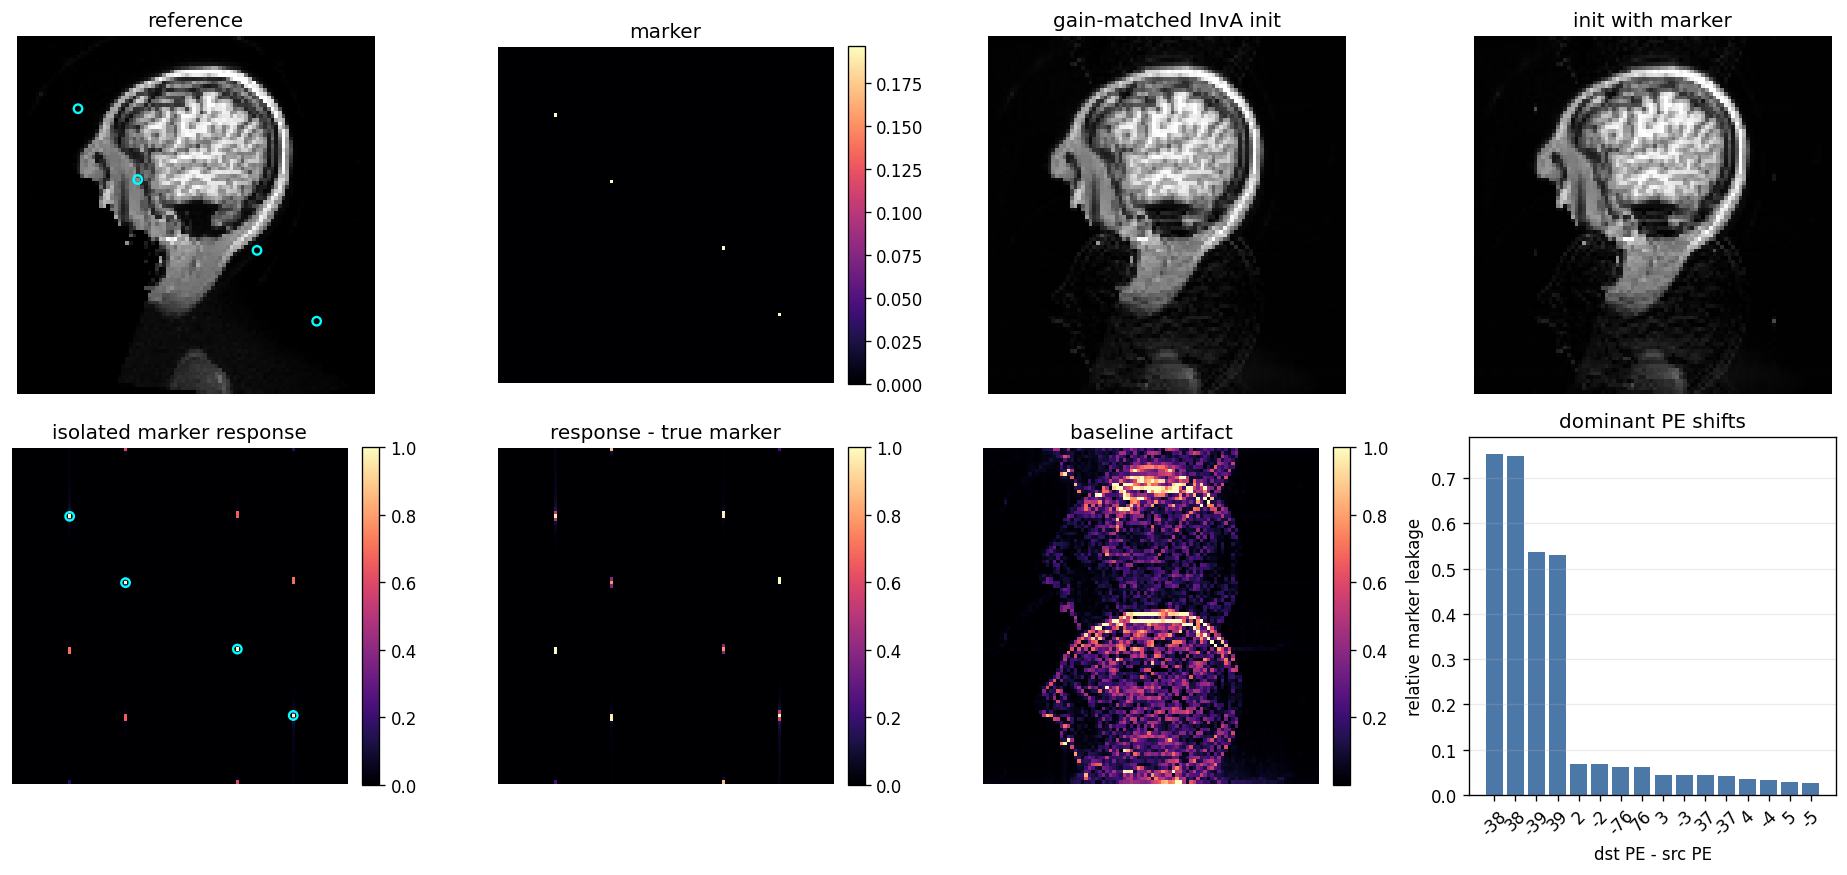

In [6]:
fig, ax = plt.subplots(2, 4, figsize=(15.5, 7.4))

show(ax[0, 0], robust_abs01(x_true[0]), "reference")
show(ax[0, 1], marker.abs()[0], "marker", cmap="magma", vmax=marker_amp, colorbar=True)
show(ax[0, 2], robust_abs01(x0[0]), "gain-matched InvA init")
show(ax[0, 3], robust_abs01(x0_marked[0]), "init with marker")

show(ax[1, 0], robust_abs01(marker_response[0], 99.0), "isolated marker response", cmap="magma", colorbar=True)
show(ax[1, 1], robust_abs01(marker_response[0] - marker[0], 99.0), "response - true marker", cmap="magma", colorbar=True)
show(ax[1, 2], robust_abs01((x0 - x_true)[0], 99.0), "baseline artifact", cmap="magma", colorbar=True)

for probe in probes:
    ax[0, 0].scatter(probe["ro"], probe["pe"], s=26, facecolors="none", edgecolors="cyan", linewidths=1.4)
    ax[1, 0].scatter(probe["ro"], probe["pe"], s=26, facecolors="none", edgecolors="cyan", linewidths=1.4)

plot_shifts = [shift for shift, _ in shift_scores[:16]]
plot_scores = [score for _, score in shift_scores[:16]]
ax[1, 3].bar([str(s) for s in plot_shifts], plot_scores, color="#4c78a8")
ax[1, 3].set_title("dominant PE shifts")
ax[1, 3].set_xlabel("dst PE - src PE")
ax[1, 3].set_ylabel("relative marker leakage")
ax[1, 3].tick_params(axis="x", rotation=45)
ax[1, 3].grid(True, axis="y", alpha=0.25)

plt.tight_layout()

## 5. Takeaway

The marker trick works as a diagnostic: after subtraction, the marker ghosts reveal the PE offsets of the leakage. For this matrix the strongest offsets are around `+38/+39` and `-38/-39` PE pixels.

This does not by itself make a complete correction, because the leakage strength changes with PE position. Use the shifts as evidence for a structured inverse or for checking whether a correction is moving the right copies.

In [7]:
def probe_response_from_corrected_data(y_corrected: torch.Tensor, marker: torch.Tensor):
    """Use this on real corrected data: add AFinal @ marker, then subtract the unmarked InvA image."""
    x_seed_raw = InvA @ y_corrected
    gain = fit_complex_gain(AFinal @ x_seed_raw, y_corrected)
    x_seed = gain * x_seed_raw

    y_probe = y_corrected + AFinal @ marker
    x_probe = gain * (InvA @ y_probe)
    return x_probe - x_seed, x_seed, gain


print("For real corrected y, call: marker_response, x_seed, gain = probe_response_from_corrected_data(y, marker)")

For real corrected y, call: marker_response, x_seed, gain = probe_response_from_corrected_data(y, marker)
